In [1]:
import xarray as xr
from glob import glob
from datetime import datetime
import yaml
import sys
sys.path.append('../../')

import plotting

from conf.global_settings import OUTPUT_DIR
from utils.pipeline_utils.file_utils import get_date
from transformations.grid_transformation import Transformation

In [10]:
ds_name = "SSMIS_OSI-450-a1_daily"
hemisphere = 'south'
with open(f'conf/ds_configs/{ds_name}.yaml', 'r') as stream:
    config = yaml.load(stream, yaml.Loader)

# Load sample granule

In [11]:
ds_granules_dir = f'{OUTPUT_DIR}/{ds_name}/harvested_granules/'
ds_granules = glob(f'{ds_granules_dir}/**/*.nc*')
if config.get("hemi_pattern"):
    print(config["hemi_pattern"][hemisphere])
    ds_granules = [g for g in ds_granules if config["hemi_pattern"][hemisphere] in g]
sample_granule_path = ds_granules[0]
print(sample_granule_path)

_sh_
/Users/marlis/Developer/ECCO/ecco_output/SSMIS_OSI-450-a1_daily/harvested_granules/2020/ice_conc_sh_ease2-250_cdr-v3p1_202012291200.nc


In [12]:
filename_date_str = get_date(config['filename_date_regex'], sample_granule_path.split('/')[-1])
granule_date = datetime.strptime(filename_date_str, config['filename_date_fmt']).strftime('%Y-%m-%dT%H:%M:%SZ')
ds = xr.open_dataset(sample_granule_path)
ds

<xarray.Dataset>
Dimensions:                         (time: 1, nv: 2, xc: 432, yc: 432)
Coordinates:
  * time                            (time) datetime64[ns] 2020-12-29T12:00:00
  * xc                              (xc) float64 -5.388e+03 ... 5.388e+03
  * yc                              (yc) float64 5.388e+03 ... -5.388e+03
    lat                             (yc, xc) float32 ...
    lon                             (yc, xc) float32 ...
Dimensions without coordinates: nv
Data variables:
    Lambert_Azimuthal_Grid          int32 ...
    time_bnds                       (time, nv) datetime64[ns] ...
    ice_conc                        (time, yc, xc) float64 ...
    raw_ice_conc_values             (time, yc, xc) float64 ...
    total_standard_uncertainty      (time, yc, xc) float64 ...
    smearing_standard_uncertainty   (time, yc, xc) float64 ...
    algorithm_standard_uncertainty  (time, yc, xc) float64 ...
    status_flag                     (time, yc, xc) float32 ...
Attributes: (12/43)
    title:                     Sea Ice Concentration Climate Data Record Vers...
    summary:                   This climate data record of sea ice concentrat...
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    geospatial_lat_min:        -90.0
    geospatial_lat_max:        -16.62393
    geospatial_lon_min:        -180.0
    ...                        ...
    product_version:           3.1
    doi:                       10.15770/EUM_SAF_OSI_0023
    product_id:                osi-450-a1
    references:                Product User Manual (2025),Algorithm Theoretic...
    history:                   2022-06-08T14:58:37Z creation\n2025-02-14T09:4...
    license:                   http://creativecommons.org/licenses/by/4.0/

# Load grid

In [13]:
grids = glob(f'grids/*.nc*')
grids.sort()
f'Available grids: {grids}'

"Available grids: ['grids/ECCO_llc270.nc', 'grids/ECCO_llc90.nc', 'grids/TPOSE.nc', 'grids/polar_stereo_n_25km.nc']"

In [14]:
grid_ds = xr.open_dataset(grids[1])
grid_ds

<xarray.Dataset>
Dimensions:                (tile: 13, j: 90, i: 90)
Coordinates:
  * tile                   (tile) int16 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j                      (j) int16 0 1 2 3 4 5 6 7 ... 82 83 84 85 86 87 88 89
  * i                      (i) int16 0 1 2 3 4 5 6 7 ... 82 83 84 85 86 87 88 89
Data variables:
    XC                     (tile, j, i) float32 ...
    YC                     (tile, j, i) float32 ...
    effective_grid_radius  (tile, j, i) float32 ...
Attributes:
    name:                  ECCO_llc90
    type:                  llc
    geospatial_lat_min:    -89.873055
    geospatial_lat_max:    89.739395
    geospatial_lon_min:    -179.98895
    geospatial_lon_max:    179.98691
    geospatial_lat_units:  degrees_north
    geospatial_lon_units:  degrees_east

In [15]:
T = Transformation(config, sample_granule_path, granule_date)

# Make mapping factors

In [16]:
factors = T.make_factors(grid_ds)

Only using 100 nearest neighbours, but you may need up to 4900266
Creating ECCO_llc90 mapping factors...done.


# Transformation

In [17]:
field_ds_list = T.transform(grid_ds, factors, ds)

In [18]:
field_ds = field_ds_list[0][0]
field_ds

<xarray.Dataset>
Dimensions:                              (time: 1, tile: 13, j: 90, i: 90, nv: 2)
Coordinates:
  * time                                 (time) datetime64[ns] 2020-12-28T12:...
  * tile                                 (tile) int16 0 1 2 3 4 ... 8 9 10 11 12
  * j                                    (j) int16 0 1 2 3 4 ... 85 86 87 88 89
  * i                                    (i) int16 0 1 2 3 4 ... 85 86 87 88 89
    XC                                   (tile, j, i) float32 -111.6 ... -111.9
    YC                                   (tile, j, i) float32 -88.24 ... -88.1
    time_bnds                            (time, nv) datetime64[ns] 2020-12-28...
Dimensions without coordinates: nv
Data variables:
    ice_conc_interpolated_to_ECCO_llc90  (time, tile, j, i) float64 9.969e+36...
Attributes:
    interpolated_grid:            ECCO_llc90
    model_grid_type:              llc
    original_dataset_title:       Global Sea Ice Concentration climate data r...
    original_dataset_short_name:  Global Sea Ice Concentration climate data r...
    original_dataset_url:         https://osi-saf.eumetsat.int/products/osi-4...
    original_dataset_reference:   https://osisaf-hl.met.no/sites/osisaf-hl/fi...
    original_dataset_doi:         10.15770/EUM_SAF_OSI_0023
    interpolated_grid_id:         ECCO_llc90
    transformation_version:       1.0
    notes:

# Visualization

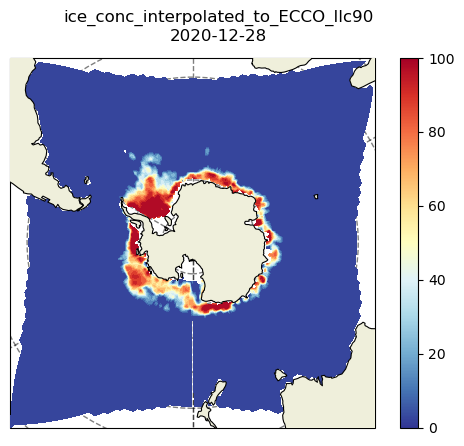

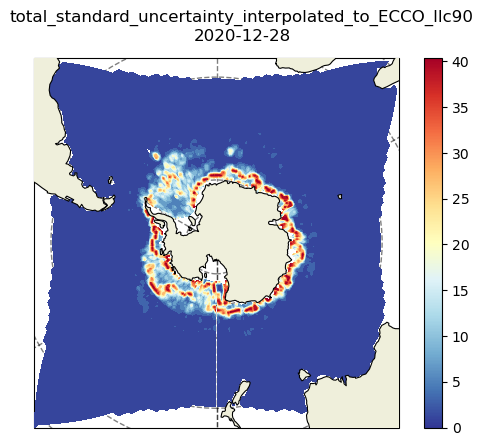

In [19]:
for field_ds in field_ds_list:
    plotting.make_plot(field_ds[0][list(field_ds[0].data_vars)[0]], 'sh')